<a href="https://colab.research.google.com/github/javigallego4/TFG/blob/main/Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

from IPython.display import clear_output, display_html
import gc; gc.enable()
import warnings
import os
from pathlib import Path
from tqdm import tqdm

# Basic libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sc
from scipy import stats
import random
import cv2

# Preprocessing
from sklearn.preprocessing import *

# PyTorch 
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau 
from PIL import Image

# MaskRCNN class imports
from typing import Any, Callable, Optional
from torchvision.models.detection.mask_rcnn import _resnet_fpn_extractor
from torch import nn
from torchvision.ops import MultiScaleRoIAlign
from torchvision.ops import misc as misc_nn_ops
from torchvision.transforms._presets import ObjectDetection

from torchvision.models.detection.mask_rcnn import MaskRCNN, MaskRCNNPredictor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models import *
from torchvision.models.detection.mask_rcnn import _resnet_fpn_extractor

# Deep Lab V3 Backbones
from torchvision.models.segmentation.deeplabv3 import *
from torchvision.models.segmentation import deeplabv3_resnet50, deeplabv3_resnet101, deeplabv3_mobilenet_v3_large, DeepLabV3_ResNet101_Weights

# Metric (mAP)
!pip install torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Weights and biases 
!pip install wandb
import wandb

warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

wandb.login() # 5bf911e7e682da23240c68fb146a222bf0475f7c

clear_output()
print('Number of CPUs: ', os.cpu_count())

DEBUG = False
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

Number of CPUs:  2


# Helper functions

In [7]:
#from sklearn.preprocessing import *
from sklearn.decomposition import PCA

def apply_pca(X, transformer = False, components = -1):
    aux = X.copy()
    if transformer:
        X = pd.DataFrame(transformer.fit_transform(X))
        X.columns = aux.columns    
    # Create principal components
    if components == -1:
        pca = PCA()
    else:
        pca = PCA(n_components = components)
        
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2, sharey = True)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance")    # ylim = (0.0, 1.0) o sino sharey en plt.subplots
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance"
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

def pca_image(img, scale = True): 
  ''' Performs a PCA and returns a 3-band image with the more significant bands. '''

  image = img.permute(1,2,0).numpy()

  b0 = image[:,:,0]
  b1 = image[:,:,1]
  b2 = image[:,:,2]
  b3 = image[:,:,3]
  b4 = image[:,:,4]
  b5 = image[:,:,5]
  b6 = image[:,:,6]
  b7 = image[:,:,7]

  if scale: 
    sc = MinMaxScaler()
    b0 = sc.fit_transform(b0)
    b1 = sc.fit_transform(b1)
    b2 = sc.fit_transform(b2)
    b3 = sc.fit_transform(b3)
    b4 = sc.fit_transform(b4)
    b5 = sc.fit_transform(b5)
    b6 = sc.fit_transform(b6)
    b7 = sc.fit_transform(b7)

  pca_df = pd.DataFrame({'B0': b0.flatten(), 'B1': b1.flatten(), 'B2': b2.flatten(), 'B3':b3.flatten(), 
              'B4': b4.flatten(), 'B5': b5.flatten(), 'B6': b6.flatten(), 'B7':b7.flatten()})
  
  global_pca, X_pca, loadings = apply_pca(pca_df)

  #X_pca = global_pca.transform(pca_df)
  component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
  X_pca = pd.DataFrame(X_pca, columns=component_names)

  img = X_pca.loc[:,:'PC3']
  sc = MinMaxScaler()
  img = pd.DataFrame(sc.fit_transform(img))
  img = img.values.reshape((image.shape[0], image.shape[1], 3))

  return torch.from_numpy(img.astype(float)).permute(2,0,1)

def vegetation_indexes(img):
  ''' Returns 3 selected vegetation indexes for the image given.

      %0	Coastal	400	425	450	50	1.24	
      %1	Blue	450	480	510	60	1.24	
      %2	Green	510	545	580	70	1.24	
      %3	Yellow	585	605	625	40	1.24	
      %4	Red	630	660	690	60	1.24	
      %5	Red Edge	705	725	745	40	1.24	
      %6	Near-IR1	770	832.5	895	125	1.24	
      %7	Near-IR2	860	950	1040	180	1.24

      * Normalized Difference Vegetation Index (NDVI) -> (NIR2-Red)/(NIR2 + Red)	UAV/WV-3
      * Green Normalized Difference Vegetation Index  -> (GNDVI)	(NIR2-Green)/(NIR2 + Green)	UAV/WV-3
      * Structure Insensitive Pigment Index (SIPI)	  ->  (NIR1-Blue)/(NIR1 + Red)	WV-3 '''

  # Colour Bands
  nir1 = img[6,:,:]
  nir2 = img[7,:,:]
  red = img[4,:,:]
  green = img[2,:,:]
  blue = img[1,:,:]

  # Vegetation Indexes
  ndvi = (nir2 - red) / (nir2 + red)
  gndvi = (nir2 - green) / (nir2 + green)
  sipi = (nir1 - blue) / (nir1 + red)

  img = torch.stack([ndvi, gndvi, sipi], axis = 0)
  img = torch.clamp(img, min=0, max=50)

  return img

def extract_image_targets(m):
  ''' Given the mask of a multispectral image, it returns both the instance masks list
      and their respective bounding boxes coordinates. '''

  num_components, masks, stats, centroids = cv2.connectedComponentsWithStats(m.to(torch.uint8).numpy())

  # Find the unique labels in the mask
  labels, counts = torch.unique(torch.from_numpy(masks), return_counts=True)

  # Create an empty list to store the instance masks
  instance_masks = []

  # Iterate over the unique labels and create a separate mask for each one
  for label in labels[1:]:
      instance_mask = torch.where(torch.from_numpy(masks) == label, torch.ones_like(torch.from_numpy(masks)), torch.zeros_like(torch.from_numpy(masks)))
      instance_masks.append(instance_mask)

  # Obtain bounding boxes coordinates
  boxes = torch.zeros([len(instance_masks),4], dtype=torch.float32)
  for i in range(len(instance_masks)):
      x,y,w,h = cv2.boundingRect(instance_masks[i].numpy().astype(np.uint8))
      boxes[i] = torch.tensor([x-1, y-1, x+w, y+h])

  return instance_masks, boxes

def show_masks_with_boxes(instance_masks, boxes): 
  ''' Shows a plot with each object mask, bounded by a rectangle. '''

  n_objects = len(instance_masks)
  plt.figure(figsize=(4*n_objects, 4))
  for i in range(n_objects):
    plt.subplot(1,n_objects, i+1)
    plt.imshow(instance_masks[i])

    # Draw the bounding rectangle
    x1, y1, x2, y2 = boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3]
    plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='r'))
  plt.show()

# Metric: mean Average Precision (mAP)

In [ ]:
if DEBUG: 
  preds = [
    dict(
      boxes=torch.tensor([[258.0, 41.0, 606.0, 285.0]]),
      scores=torch.tensor([0.536]),
      labels=torch.tensor([0]),
    )
  ]
  target = [
    dict(
      boxes=torch.tensor([[214.0, 41.0, 562.0, 285.0]]),
      labels=torch.tensor([0]),
    )
  ]
  metric = MeanAveragePrecision()
  metric.update(preds, target)
  print(metric.compute()['map'])

# Dataset


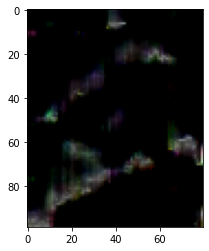

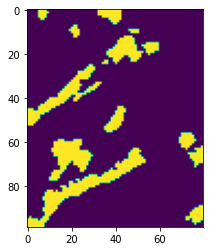

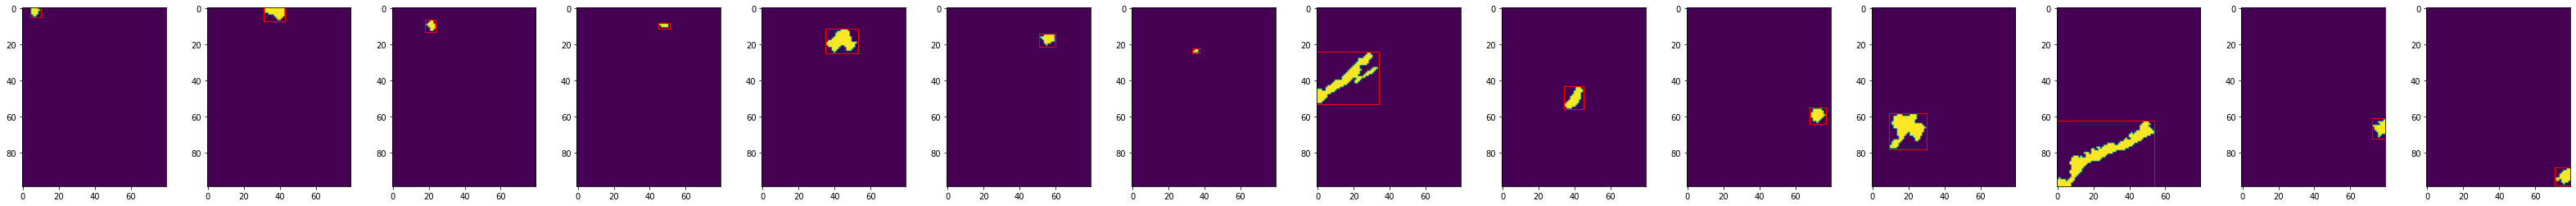

In [8]:
class PanchromaticDataset(torch.utils.data.Dataset):
    def __init__(self, images, masks):
      super().__init__()
      self.images = images 
      self.masks = masks 

    def __getitem__(self, i):
      return torch.from_numpy(self.images[i].astype(float)), torch.from_numpy(self.masks[i].astype(float))
        
    def __len__(self):
      return len(self.images)

class MultispectralDataset(torch.utils.data.Dataset):
  def __init__(self, images, masks, approach):
    super().__init__()
    self.images = images 
    self.masks = masks 
    self.approach = approach

  def __getitem__(self, i):
    img, mask = torch.from_numpy(self.images[i].astype(float)).permute(2,0,1), torch.from_numpy(self.masks[i].astype(float))
    
    if self.approach == '': return img, mask
    if self.approach == 'vegetation indexes': return torch.nan_to_num(vegetation_indexes(img)), mask
    if self.approach == 'pca': return pca_image(img), mask

  def __len__(self):
    return len(self.images)

panchromatic_dataset = torch.load('/content/gdrive/MyDrive/panchromatic_dataset.pt')
multispectral_dataset = torch.load('/content/gdrive/MyDrive/multispectral_dataset.pt')

if DEBUG: 
  img, mask = multispectral_dataset[1]
  instance_masks, boxes = extract_image_targets(mask)
  plt.imshow(img.permute(1,2,0))
  plt.show()
  plt.imshow(mask)
  show_masks_with_boxes(instance_masks, boxes)

In [ ]:
#run = wandb.init(project="Bachelor Thesis", entity="javigallego4")

# loggear las imágenes
#dataloader = torch.utils.data.DataLoader(panchromatic_dataset, batch_size = 1)
#for i, (img, mask) in enumerate(dataloader):
#    wandb.log({"{}".format(i): wandb.Image(img)})

#run = wandb.init(project="Bachelor Thesis", entity="javigallego4")
#dataloader = torch.utils.data.DataLoader(multispectral_dataset, batch_size = 1)
#for i, (img, mask) in tqdm(enumerate(dataloader)):
#  plt.imshow(img.squeeze().permute(1,2,0))
#  wandb.log({"Not Masked: {}".format(i): plt})

#run = wandb.init(project="Bachelor Thesis", entity="javigallego4")
#dataloader = torch.utils.data.DataLoader(multispectral_dataset, batch_size = 1)
#for i, (img, mask) in tqdm(enumerate(dataloader)):
#  fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (8,4))

#  axes[0].imshow(img.squeeze().permute(1,2,0))
#  axes[1].imshow(img.squeeze().permute(1,2,0))
#  axes[1].imshow(mask.squeeze(), alpha = .5)

#  wandb.log({"{}".format(i): fig})
#run.finish()

# Model

## Model Analysis

https://discuss.pytorch.org/t/bug-issue-loading-pretrained-fcos-resnet50-fpn/153684

In [ ]:
from torchvision.models import ResNet50_Weights
from torchvision.models.detection import *
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

MaskRCNN por defecto tiene 91 clases distintas. En nuestro caso, solo tenemos 2: el background y los jeniperus. Por tanto, tenemos que modificar la arquitectura de la red para poder realizar de forma correcta nuestro entrenamiento. 

* La arquitectura de red está formada por distintos módulos. Al backbone ni caso. Nos centramos en el ROI_HEADS.

In [ ]:
#maskrcnn_resnet50_fpn(weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT).roi_heads

Vemos que hay varios parámetros puestos a 91. Hay que cambiarlos a 2. 

* (cls_score) = classes_score -> out_features
* (mask_predictor) -> mask_fcn_logits -> out_channels (2o argumento).

In [ ]:
#m = maskrcnn_resnet50_fpn(weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
#m.roi_heads.box_predictor.cls_score = nn.Linear(1024,2,True)
#m.roi_heads.mask_predictor.mask_fcn_logits = nn.Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))
#m.roi_heads

!git clone https://github.com/matterport/Mask_RCNN
Then just run the setup.py file from that directory,
!sudo python setup.py install

os.chdir("/content/Mask_RCNN")
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.engine.topology as KE

from mrcnn.config import Config
from mrcnn import utils
import mrcnn.model as modellib
from mrcnn import visualize
from mrcnn.model import log

In [ ]:
#multispectral_dataset[0][0] # !OJO! Tiene valores NAN plc

Los outputs principales de MaskRCNN en PyTorch son:

scores: un tensor de probabilidades de clase para cada región propuesta, indicando la probabilidad de que una región contenga un objeto de cada clase.
boxes: un tensor de coordenadas de las cajas delimitadoras para cada región propuesta, indicando la posición de cada objeto detectado en la imagen.
masks: un tensor de máscaras binarias para cada objeto detectado, indicando la posición de cada objeto en la imagen.
labels: un tensor de etiquetas de clase para cada objeto detectado, indicando la clase a la que pertenece cada objeto detectado.

## Model Implementation

In [ ]:
class maskrcnn_resnet_50_fpn(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights = 'DEFAULT') 
               
        # Replace the classifier with a new one, that has num_classes which is user-defined
        num_classes = 2  # In this case two classes: "jeniperus" and "background"
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features # get number of input features for the classifier
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes) # replace the pre-trained head with a new one

        # Change the anchor generator
        self.model.roi_heads.box_predictor.anchor_generator = AnchorGenerator(
            sizes=((2, 4, 8, 16, 32, 64),),
            aspect_ratios=((0.125, 0.25, 0.5, 1.0, 2.0, 3.0, 4.0),)
        )

        # now get the number of input features for the mask classifier
        in_features_mask = self.model.roi_heads.mask_predictor.conv5_mask.in_channels
        hidden_layer = 256
        # and replace the mask predictor with a new one
        self.model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
        
    def forward(self, inputs, targets):
        #transforms = self.weights.transforms()
        #inputs = [transforms(d) for d in inputs]
        #targets = [transforms(d) for d in targets]

        x = self.model(inputs, targets)
        return x
      
    def predict(self, x):
        #transforms = self.weights.transforms()
        #x = [transforms(d) for d in x]
        x = self.model(x)
        return x

class maskrcnn_resnet_50_fpn_v2(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(weights = 'DEFAULT') 
               
        # Replace the classifier with a new one, that has num_classes which is user-defined
        num_classes = 2  # In this case two classes: "jeniperus" and "background"
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features # get number of input features for the classifier
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes) # replace the pre-trained head with a new one

        # Change the anchor generator
        self.model.roi_heads.box_predictor.anchor_generator = AnchorGenerator(
            sizes=((2, 4, 8, 16, 32, 64),),
            aspect_ratios=((0.125, 0.25, 0.5, 1.0, 2.0, 3.0, 4.0),)
        )

        # now get the number of input features for the mask classifier
        in_features_mask = self.model.roi_heads.mask_predictor.conv5_mask.in_channels
        hidden_layer = 256
        # and replace the mask predictor with a new one
        self.model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
        
    def forward(self, inputs, targets):
        #transforms = self.weights.transforms()
        #inputs = [transforms(d) for d in inputs]
        #targets = [transforms(d) for d in targets]

        x = self.model(inputs, targets)
        return x
      
    def predict(self, x):
        #transforms = self.weights.transforms()
        #x = [transforms(d) for d in x]
        x = self.model(x)
        return x

class maskrcnn_mobilenet_v2(nn.Module):
    def __init__(self):
        super().__init__()

        # Constructing backbone
        self.backbone_weights = torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1
        backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
        backbone.out_channels = 1280

        anchor_generator = AnchorGenerator(sizes=((32, 64, 128, 256, 512),),
                                   aspect_ratios=((0.5, 1.0, 2.0),))

        roi_pooler = torchvision.ops.MultiScaleRoIAlign(featmap_names=['0'],
                                                        output_size=7,
                                                        sampling_ratio=2)

        # put the pieces together inside a MaskRCNN model
        self.model = MaskRCNN(backbone, num_classes=2, rpn_anchor_generator=anchor_generator, box_roi_pool=roi_pooler)

        # Change the anchor generator from the predictor
        self.model.roi_heads.box_predictor.anchor_generator = AnchorGenerator(
            sizes=((2, 4, 8, 16, 32, 64),),
            aspect_ratios=((0.125, 0.25, 0.5, 1.0, 2.0, 3.0, 4.0),)
        )
        
    def forward(self, inputs, targets):
        #transforms = self.backbone_weights.transforms()
        #inputs = [transforms(d) for d in inputs]
        #targets = [transforms(d) for d in targets]

        x = self.model(inputs, targets)
        return x
      
    def predict(self, x):
        #transforms = self.backbone_weights.transforms()
        #x = [transforms(d) for d in x]
        x = self.model(x)
        return x

class maskrcnn_deeplabv3_resnet_101_fpn(nn.Module):
    def __init__(self):
        super().__init__()

        # Constructing backbone
        backbone = deeplabv3_resnet101(weights = 'DEFAULT')
        backbone.out_channels = 21

        anchor_generator = AnchorGenerator(sizes=((32, 64, 128, 256, 512),),
                                           aspect_ratios=((0.5, 1.0, 2.0),))

        roi_pooler = torchvision.ops.MultiScaleRoIAlign(featmap_names=['0'],
                                                        output_size=7,
                                                        sampling_ratio=2)

        # put the pieces together inside a MaskRCNN model
        self.model = MaskRCNN(backbone, num_classes=2, rpn_anchor_generator=anchor_generator, box_roi_pool=roi_pooler)

    def forward(self, inputs, targets):
        #transforms = self.weights.transforms()
        #inputs = [transforms(d) for d in inputs]
        #targets = [transforms(d) for d in targets]

        x = self.model(inputs, targets)
        return x
      
    def predict(self, x):
        #transforms = self.weights.transforms()
        #x = [transforms(d) for d in x]
        x = self.model(x)
        return x

#class Model(nn.Module):
#    def __init__(self, backbone = 'ResNet-50', v = 'v2'):
#        super().__init__()

#        if backbone == 'ResNet-50-FPN': 
          
#              self.model = maskrcnn_resnet50_fpn_v2(weights = 'DEFAULT') 
              # Replace the classifier with a new one, that has num_classes which is user-defined
#              num_classes = 2  # For example, two classes: "person" and "background"
              # get number of input features for the classifier
#              in_features = self.model.roi_heads.box_predictor.cls_score.in_features
              # replace the pre-trained head with a new one
#              self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

#        elif backbone == 'ResNet-50-FPN-v2': 
          
#              self.model = maskrcnn_resnet50_fpn(weights = 'DEFAULT')
#              num_classes = 2  
#              in_features = self.model.roi_heads.box_predictor.cls_score.in_features
#              self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

#        elif backbone == 'DeepLabV3-ResNet-101-FPN':         

#              self.model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights = 'DEFAULT')

              # Replace the backbone with ResNet-101-FPN
#              self.model.backbone.body = torchvision.models.resnet.resnet101(weights = 'DEFAULT').body
#              self.model.backbone.out_channels = 2048

              # Replace the RPN head with DeepLab V3 head
#              self.model.rpn.head = DeepLabHead(2048, num_classes=2)

              # Replace the classification head with a Fast R-CNN predictor
#              self.model.roi_heads.box_predictor = FastRCNNPredictor(2048, num_classes=2)


        # Load a pre-trained model
        #model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)

#========================

        # Replace the classifier with a new one, that has num_classes which is user-defined
        #num_classes = 2  # For example, two classes: "person" and "background"
        # get number of input features for the classifier
        #in_features = self.model.roi_heads.box_predictor.cls_score.in_features
        # replace the pre-trained head with a new one
        #self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

        # now get the number of input features for the mask classifier
#        in_features_mask = self.model.roi_heads.mask_predictor.conv5_mask.in_channels
#        hidden_layer = 256
        # and replace the mask predictor with a new one
#        self.model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask,
 #                                                         hidden_layer,
 #                                                         num_classes)

#========================


        # Freezing initial layers
        #NUM_FROZEN_LAYERS = int(len(list(self.model.backbone.named_parameters()))) # how many layers you want to freeze
        #for name, param in list(self.model.backbone.named_parameters()):
        #    param.requires_grad = False

        # Adapt the architecture for 2 classes, rather than 91
        #self.model.roi_heads.box_predictor.cls_score = nn.Linear(1024,2,True)
        #self.model.roi_heads.mask_predictor.mask_fcn_logits = nn.Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))

    #def _init_weights(self, s):
    #    nn.init.normal_(self.head.weight, mean = 0.0, std = s)
                
  #  def forward(self, inputs, targets):
      #transforms = self.weights.transforms()
      #inputs = [transforms(d) for d in inputs]
      #targets = [transforms(d) for d in targets]

   #   x = self.model(inputs, targets)
   #   return x
    
   # def predict(self, x):
        #transforms = self.weights.transforms()
        #x = [transforms(d) for d in x]
   #     x = self.model(x)
   #     return x

if DEBUG:
    with torch.no_grad():

        print('Mask-RCNN + ResNet-50-FPN')
        model = maskrcnn_resnet_50_fpn().eval()
        pred = model.predict([torch.nan_to_num(multispectral_dataset[1][0]).to(dtype=torch.float32)])

        print('Mask-RCNN + ResNet-50-FPN V2')
        model = maskrcnn_resnet_50_fpn_v2().eval()
        pred = model.predict([torch.nan_to_num(multispectral_dataset[1][0]).to(dtype=torch.float32)])

        print('Mask-RCNN + MobileNet V2')
        model = maskrcnn_mobilenet_v2().eval()
        pred = model.predict([torch.nan_to_num(multispectral_dataset[1][0]).to(dtype=torch.float32)])

        print('Mask-RCNN + DeepLabV3_ResNet-101-FPN')
        model = maskrcnn_deeplabv3_resnet_101_fpn().eval()
        pred = model.predict([torch.nan_to_num(multispectral_dataset[1][0]).to(dtype=torch.float32)])

# Training Loop

## Helper Functions

In [ ]:
class EarlyStopping():
    """
    Early stopping to stop the training when the loss does not improve after
    certain epochs.
    """
    def __init__(self, patience=5, min_delta=0):
        """
        :param patience: how many epochs to wait before stopping when loss is
               not improving
        :param min_delta: minimum difference between new loss and old loss for
               new loss to be considered as an improvement
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss == None:
            self.best_loss = val_loss
            
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            # reset counter if validation loss improves
            self.counter = 0
            
        elif self.best_loss - val_loss < self.min_delta:
            self.counter += 1
            print(f"INFO: Early stopping counter {self.counter} of {self.patience}")
            if self.counter >= self.patience:
                print('INFO: Early stopping')
                self.early_stop = True

In [ ]:
import gc

def gc_collect():
    gc.collect()
    torch.cuda.empty_cache()

def train_one_epoch(train_loader, model, optimizer, scaler):
    # Metric
    metric = MeanAveragePrecision() 

    # Track losses
    #loss_classifier = 0
    #loss_box_reg = 0
    #loss_mask = 0
    #loss_objectness = 0
    #loss_rpn_box_reg = 0
    loss_epoch = 0
    mAP_epoch, mAP50_epoch, mAP75_epoch = 0, 0, 0
    
    # Loop over minibatches
    for imgs, masks in tqdm(train_loader):
        model.train() # Train mode

        # Create MaskRCNN inputs and targets
        inputs = [imgs[i].to(device, dtype = torch.float32) for i in range(imgs.shape[0])]
        targets = []

        for i in range(imgs.shape[0]):
          instance_masks, boxes = extract_image_targets(masks[i].squeeze())
          target = {}
          target["boxes"] = boxes.to(device)
          target["labels"] = torch.ones(len(instance_masks), dtype=torch.int64).to(device)   
          target["masks"] = torch.stack(instance_masks).to(torch.uint8).to(device)
          targets.append(target)

        # Zero gradients
        optimizer.zero_grad(set_to_none=True)
        
        # Forward pass
        with torch.cuda.amp.autocast():
          outputs = model(inputs, targets)
        
        if DEBUG: 
          print('Max Value Image: ', imgs.squeeze().max())
          print('Min Value Image: ', imgs.squeeze().min())
          plt.imshow(imgs.squeeze().permute(1,2,0))
          plt.show()

          print('\n\n============================ Outputs ============================\n\n', outputs)
          print('\n\n')

        losses = sum(loss for loss in outputs.values())
        #losses.backward()
        #optimizer.step()

        # Scales the loss, and calls backward() to create scaled gradients
        scaler.scale(losses).backward()

        # Unscales gradients and calls or skips optimizer.step()
        scaler.step(optimizer)

        # Updates the scale for next iteration
        scaler.update()
            
        # Backprop
        #loss.backward()

        # Update parameters
        #optimizer.step()

        # Track losses
        loss_epoch += losses.detach().item()
        #loss_classifier += outputs['loss_classifier'].detach().item()
        #loss_box_reg += outputs['loss_box_reg'].detach().item()
        #loss_mask += outputs['loss_mask'].detach().item()
        #loss_objectness += outputs['loss_objectness'].detach().item()
        #loss_rpn_box_reg += outputs['loss_rpn_box_reg'].detach().item()

        # Track metric
        model.eval()
        pred = model.predict(inputs)

        inputs_pred = []

        for i in range(imgs.shape[0]):
          p = dict(
            boxes=pred[i]['boxes'],
            scores=pred[i]['scores'],
            labels=pred[i]['labels'],
            #masks=pred[i]['masks'].squeeze().to(torch.uint8) if pred[i]['masks'].shape[0] != 1 \
            #      else pred[i]['masks'].squeeze().unsqueeze(0).to(torch.uint8)
          )
          inputs_pred.append(p)

        #print(inputs_pred[0]['masks'].shape)
        #print(inputs_pred[0]['masks'].squeeze().shape)

        targets_pred = []
        for i in range(imgs.shape[0]):
          instance_masks, boxes = extract_image_targets(masks[i].squeeze())
          target = {}
          target["boxes"] = boxes.to(device)
          target["labels"] = torch.ones(len(instance_masks), dtype=torch.int64).to(device)   
          targets_pred.append(target)

        metric = MeanAveragePrecision(iou_type = 'bbox') 
        metric.update(inputs_pred, targets_pred)
        m = metric.compute()
        mAP_epoch += m['map']
        mAP50_epoch += m['map_50']
        mAP75_epoch += m['map_75']
        
        del inputs, targets, inputs_pred, outputs
        gc_collect()
        
    return loss_epoch/len(train_loader), mAP_epoch/len(train_loader), mAP50_epoch/len(train_loader), mAP75_epoch/len(train_loader), model

if DEBUG: 
  gc_collect()
  model = maskrcnn_resnet_50_fpn()
  model = model.to(device)

  dataloader = torch.utils.data.DataLoader(multispectral_dataset, batch_size = 4, num_workers = os.cpu_count(), pin_memory=True)
  optimizer = optim.AdamW(model.parameters())
  scaler = torch.cuda.amp.GradScaler()
  loss, mAP, mAP50, mAP75, model = train_one_epoch(dataloader, model, optimizer, scaler)

In [ ]:
def validate_one_epoch(validation_loader, model):
    # Track losses
    #loss_classifier = 0
    #loss_box_reg = 0
    #loss_mask = 0
    #loss_objectness = 0
    #loss_rpn_box_reg = 0
    loss_epoch = 0
    mAP_epoch, mAP50_epoch, mAP75_epoch = 0, 0, 0
    
    # Don't update weights
    with torch.no_grad():

      # Loop over minibatches
      for imgs, masks in tqdm(validation_loader):
          model.train()

          # Create MaskRCNN inputs and targets
          inputs = [imgs[i].to(device, dtype = torch.float32) for i in range(imgs.shape[0])]
          targets = []

          for i in range(imgs.shape[0]):
            instance_masks, boxes = extract_image_targets(masks[i].squeeze())
            target = {}
            target["boxes"] = boxes.to(device)
            target["labels"] = torch.ones(len(instance_masks), dtype=torch.int64).to(device)   
            target["masks"] = torch.stack(instance_masks).to(torch.uint8).to(device)
            targets.append(target)

          # Make predictions and obtain losses
          with torch.cuda.amp.autocast():
            outputs = model(inputs, targets)

          losses = sum(loss for loss in outputs.values())

          # Track loss
          loss_epoch += losses.detach().item()

          # Track metric
          model.eval()
          pred = model.predict(inputs)

          inputs_pred = []

          for i in range(imgs.shape[0]):
            p = dict(
              boxes=pred[i]['boxes'],
              scores=pred[i]['scores'],
              labels=pred[i]['labels'],
              #masks=pred[i]['masks'].squeeze().to(torch.uint8) if pred[i]['masks'].shape[0] != 1 \
              #      else pred[i]['masks'].squeeze().unsqueeze(0).to(torch.uint8)
            )
            inputs_pred.append(p)

          targets_pred = []

          for i in range(imgs.shape[0]):
            instance_masks, boxes = extract_image_targets(masks[i].squeeze())
            target = {}
            target["boxes"] = boxes.to(device)
            target["labels"] = torch.ones(len(instance_masks), dtype=torch.int64).to(device)   
            targets_pred.append(target)

          metric = MeanAveragePrecision(iou_type = 'bbox') 
          metric.update(inputs_pred, targets_pred)
          m = metric.compute()
          mAP_epoch += m['map']
          mAP50_epoch += m['map_50']
          mAP75_epoch += m['map_75']

          del inputs, targets, inputs_pred
          gc_collect()
            
    return loss_epoch/len(validation_loader), mAP_epoch/len(validation_loader), mAP50_epoch/len(validation_loader), mAP75_epoch/len(validation_loader)
    #return loss_epoch/len(validation_loader), pfbeta_epoch/len(validation_loader), threshold

## Main Function

In [ ]:
def train_model(verbose=True):
    torch.manual_seed(42)
    # Init W&B 
    run = wandb.init(project="Bachelor Thesis", entity="javigallego4", group = 'Tuning')
    
    # Model and Dataset
    model = maskrcnn_resnet_50_fpn() if wandb.config.backbone == 'ResNet-50-FPN' else \
            maskrcnn_resnet_50_fpn_v2() if wandb.config.backbone == 'ResNet-50-FPN V2' else maskrcnn_mobilenet_v2()
    model = model.to(device)
    
    # Freezing initial layers
    NUM_FROZEN_LAYERS = int(len(list(model.named_parameters())) * wandb.config.freezing) # how many layers you want to freeze
    for name, param in list(model.named_parameters())[0:NUM_FROZEN_LAYERS]:
        param.requires_grad = False
        
    # Datasets    
    n = len(multispectral_dataset)
    train_data, validation_data = random_split(multispectral_dataset, [int(n*0.8), int(n*0.2)+1])

    # Construct an optimizer and scheduler
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(params, lr = wandb.config.lr, weight_decay = wandb.config.weight_decay, amsgrad = wandb.config.amsgrad) if wandb.config.optimizer == 'AdamW' \
                else optim.SGD(params, lr=wandb.config.lr)
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=2, threshold = wandb.config.threshold, verbose = True)

    # Gradient scaling helps prevent gradients with small magnitudes from flushing to zero (“underflowing”) when training with mixed precision.
    scaler = torch.cuda.amp.GradScaler()
    
    #for i in range(wandb.config.folds): 
    #   train_idx = train[train.VAL_FOLD != i].index
    #    val_idx = train[train.VAL_FOLD == i].index
    batch = wandb.config.batch_size if wandb.config.backbone == 'ResNet-50-FPN' else int(wandb.config.batch_size / 2)     
    trainloader = torch.utils.data.DataLoader(train_data, batch_size = batch, num_workers = 4, shuffle = True, pin_memory=True)
    validationloader = torch.utils.data.DataLoader(validation_data, batch_size = batch, num_workers = 4, pin_memory=True)
        
        #print('====== Fold: {} ======='.format(i))
    
    best_mAP = 0
    early_stopping = EarlyStopping(5, 0.005)

    # Loop over epochs
    for epoch in range(wandb.config.epochs):
            
          # Train
          train_loss, train_mAP, train_mAP50, train_mAP75, model = train_one_epoch(trainloader, model, optimizer, scaler)
          
          # Evaluate
          val_loss, val_mAP, val_mAP50, val_mAP75 = validate_one_epoch(validationloader, model)

          # Apply scheduler
          scheduler.step(val_loss)
          
          # Log metrics
          wandb.log({
              'epoch': epoch,
              'train_loss': train_loss,
              'val_loss': val_loss,
              'train_mAP': train_mAP,
              'train_mAP50': train_mAP50, 
              'train_mAP75': train_mAP75, 
              'val_mAP': val_mAP,
              'val_mAP50': val_mAP50,
              'val_mAP75': val_mAP75 
          })

          # Print loss
          if verbose:
              if (epoch+1)%1==0:
                  print(f'\nEpoch {epoch+1}/{wandb.config.epochs}')
                  print(f'loss {train_loss:.5f}, val_loss {val_loss:.5f}')
                  print(f'mAP {train_mAP:.5f}, mAP50 {train_mAP50:.5f}, mAP75 {train_mAP75:.5f}, val_mAP {val_mAP:.10f}, val_mAP50 {val_mAP50:.5f}, val_mAP75 {val_mAP75:.5f}')
  
          # Early Stopping
          early_stopping(val_loss)
          if early_stopping.early_stop:
              break
          else:
              if val_mAP > best_mAP: 
                  best_mAP = val_mAP
                  best_model_state_dic = model.state_dict()

          print('\n')

    #cv_val_metric.append(best_pf1)
    wandb.log({'best_mAP':best_mAP})
    #wandb.log({'cv_val_metric': np.mean(cv_val_metric)})
  
    # Save the best model as W&B Artifact  
    PATH = "{}.pt".format(wandb.run.name)
    torch.save(best_model_state_dic, PATH)

    artifact = wandb.Artifact(name='{}'.format(run.name), type='model')
    artifact.add_file('{}.pt'.format(run.name))
    run.log_artifact(artifact)
    run.finish()

## W&B Sweeps

In [ ]:
# Vegetation Indexes: iwfu9bth
# PCA: c3kjpfxp

%env SWEEP_ID=c3kjpfxp
#os.environ.__delitem__('SWEEP_ID')

env: SWEEP_ID=c3kjpfxp


In [ ]:
gc_collect()
sweep_id = os.environ.get('SWEEP_ID')
print('wandb sweep ', sweep_id)

if sweep_id is None:
    # Define the sweep configuration
    sweep_id = wandb.sweep(sweep={
            'method': 'bayes',
            'name': 'MaskRCNN PCA',
            'metric': {'goal': 'maximize', 'name': 'best_mAP'},
            'parameters':
                {   
                    # Dataset Config
                    'approach': {'values': ['PCA']},

                    # Model config
                    'backbone': {'values': ['ResNet-50-FPN', 'ResNet-50-FPN V2', 'MobileNet V2']},
                 
                    # Training config
                    'batch_size' : {'values': [8]}, 
                    'epochs': {'values': [60]},
                    'freezing': {'values': [0.25, 0.5, 0.75]}, 
                    'image_size': {'values': [(25,21)]},
                    'dataset_split': {'values': [(0.8, 0.2)]},
                    
                    # Optimizer configuration.  
                    'optimizer': {'values': ['AdamW']},
                    'lr': {'distribution': 'uniform', "min": 1e-04, "max": 1e-02}, 
                    'weight_decay': {'distribution': 'uniform', "min": 1e-03, "max": 1e-01},
                    'amsgrad': {'values': [True, False]},
                 
                    # Lr Scheduler
                    'scheduler': {'values': ['ReduceLROnPlateau']},
                    'threshold': {'values': [0.005]},

                    # Metric 
                    'mAP_type': {'values': ['bbox']},
                    
                }
        }, project="Bachelor Thesis")

    print('Generated sweep id', sweep_id)

else:
    """
    Agent run. Use sweep_id generated above to produce (semi)-random hyperparameters run.config
    """
    wandb.agent(sweep_id, function=train_model, entity="javigallego4", project="Bachelor Thesis", count = 2)

wandb sweep  c3kjpfxp


wandb: Agent Starting Run: mjhqolkd with config:
wandb: 	amsgrad: False
wandb: 	approach: PCA
wandb: 	backbone: ResNet-50-FPN
wandb: 	batch_size: 8
wandb: 	dataset_split: [0.8, 0.2]
wandb: 	epochs: 60
wandb: 	freezing: 0.75
wandb: 	image_size: [25, 21]
wandb: 	lr: 0.008725181954236277
wandb: 	mAP_type: bbox
wandb: 	optimizer: AdamW
wandb: 	scheduler: ReduceLROnPlateau
wandb: 	threshold: 0.005
wandb: 	weight_decay: 0.0966258977658204
ERROR:wandb.jupyter:Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING Ignored wandb.init() arg project when running a sweep.
wandb: WARNING Ignored wandb.init() arg entity when running a sweep.


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


  0%|          | 0.00/170M [00:00<?, ?B/s]

100%|██████████| 177/177 [09:29<00:00,  3.22s/it]



Epoch 1/60
loss nan, val_loss 1.02111
mAP 0.02049, mAP50 0.08034, mAP75 0.00321, val_mAP 0.0247227699, val_mAP50 0.09429, val_mAP75 0.00380




 50%|█████     | 355/705 [19:05<19:46,  3.39s/it]